## Purpose
This notebook is to calculate stocks with a 14-day RSI of 75 and identify the first 25 highest RSI stocks.
This stock is considered overbought, meaning it may have risen too quickly, and a pullback could be imminent.

In [1]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType
from config_loader import load_config

In [2]:
tablename = 'stocksinfp'
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp


In [3]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

25/06/15 00:46:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/06/15 00:46:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [5]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 180)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter(col("Symbol") == 'AAPL')
# Show the result
filtered_df.printSchema()
filtered_df.show(2, truncate=False)

root
 |-- Date: date (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- price_change: double (nullable = true)

+----------+-----------------+-----------------+------------------+------------------+------------------+--------+------+----------------+
|Date      |Open             |High             |Low               |Close             |Adj Close         |Volume  |symbol|price_change    |
+----------+-----------------+-----------------+------------------+------------------+------------------+--------+------+----------------+
|2024-12-17|250.0800018310547|253.8300018310547|249.77999877929688|253.47999572753906|253.47999572753906|51356400|AAPL  |2.44000244140625|
|2024-12-17|170.5800018310547|176.5            |170.2100067138672 |175.3800048828125 |173.741592407

In [6]:
# Function to calculate the 14-day RSI
def calculate_rsi(df, window_size=14):
    # Calculate price change
    #df = df.withColumn('price_change', F.col('Close') - F.lag('Close', 1).over(Window.partitionBy('symbol').orderBy('Date')))

    # Calculate gain and loss
    df = df.withColumn('gain', F.when(F.col('price_change') > 0, F.col('price_change')).otherwise(0))
    df = df.withColumn('loss', F.when(F.col('price_change') < 0, -F.col('price_change')).otherwise(0))

    # Calculate rolling average gain and loss
    window_spec = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-window_size + 1, 0)
    
    df = df.withColumn('avg_gain', F.avg('gain').over(window_spec))
    df = df.withColumn('avg_loss', F.avg('loss').over(window_spec))

    # Calculate RS (Relative Strength) and RSI
    df = df.withColumn('rs', F.col('avg_gain') / F.col('avg_loss'))
    df = df.withColumn('rsi', 100 - (100 / (1 + F.col('rs'))))

    return df

In [7]:
# Apply RSI calculation
df_rsi = calculate_rsi(filtered_df)

In [8]:
# Show the result
df_rsi.select('symbol', 'Date', 'rsi').show(10)

+------+----------+------------------+
|symbol|      Date|               rsi|
+------+----------+------------------+
|  AAPL|2024-12-17|              null|
|  AAPL|2024-12-18| 31.00386220161002|
|  AAPL|2024-12-19|43.496348046999046|
|  AAPL|2024-12-20| 62.05455204623489|
|  AAPL|2024-12-23|   64.015944376695|
|  AAPL|2024-12-24| 69.86686243976294|
|  AAPL|2024-12-26| 71.17835387953482|
|  AAPL|2024-12-27| 60.21555548703824|
|  AAPL|2024-12-30| 52.26033685923127|
|  AAPL|2024-12-31|48.870270132002005|
+------+----------+------------------+
only showing top 10 rows



In [9]:
# Step 1: Filter for RSI > 75
filtered_df = df_rsi.filter(df_rsi['rsi'] > 75)

# Step 2: Get the latest available record for each stock symbol
window_spec = Window.partitionBy('symbol').orderBy(F.col('Date').desc())  # Window by symbol, ordered by date (latest first)

latest_rsi_df = filtered_df.withColumn('row_num', F.row_number().over(window_spec)) \
                            .filter(F.col('row_num') == 1) \
                            .drop('row_num')  # We keep only the latest row for each symbol

# Step 3: Get the top 25 stocks with the highest RSI
top_25_rsi_stocks = latest_rsi_df.orderBy(F.col('rsi').desc()).limit(25)

# Show the result
top_25_rsi_stocks.select('symbol', 'Date', 'rsi').show()


+------+----------+-----------------+
|symbol|      Date|              rsi|
+------+----------+-----------------+
|   ODD|2025-06-06| 98.7763404732922|
|  MVIS|2024-12-30|97.64706096847173|
|  ESEA|2025-06-13|96.91560472279642|
|   RHE|2025-01-06|96.33815667507383|
|  ORCL|2025-06-13|95.27740075839199|
|   LLY|2025-06-13|94.90776749657154|
|  ARVN|2025-04-30|   93.92096475884|
| QRTEB|2025-02-24|92.85714171674788|
|   AMC|2025-05-27| 91.3043555523174|
|  UPST|2025-06-11|90.39350300926013|
|   AWI|2025-05-20|89.73911031315953|
|   NOC|2025-06-13| 89.6250183909345|
|  NURO|2025-05-09|89.39396785534181|
|    DQ|2025-01-07|89.05473014499327|
|  DRIP|2025-04-08|88.83713983458617|
|   YOU|2025-03-19|88.82601943063369|
|   GME|2025-05-27|88.56404377553314|
|   NET|2025-06-11|87.92929953410088|
|   IOT|2025-05-20|87.53682738317625|
|  PTGX|2025-06-13|87.31707394877832|
+------+----------+-----------------+
only showing top 20 rows



/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_3738/3445727300.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rsi', y='symbol', data=top_25_rsi_pandas, palette='coolwarm')


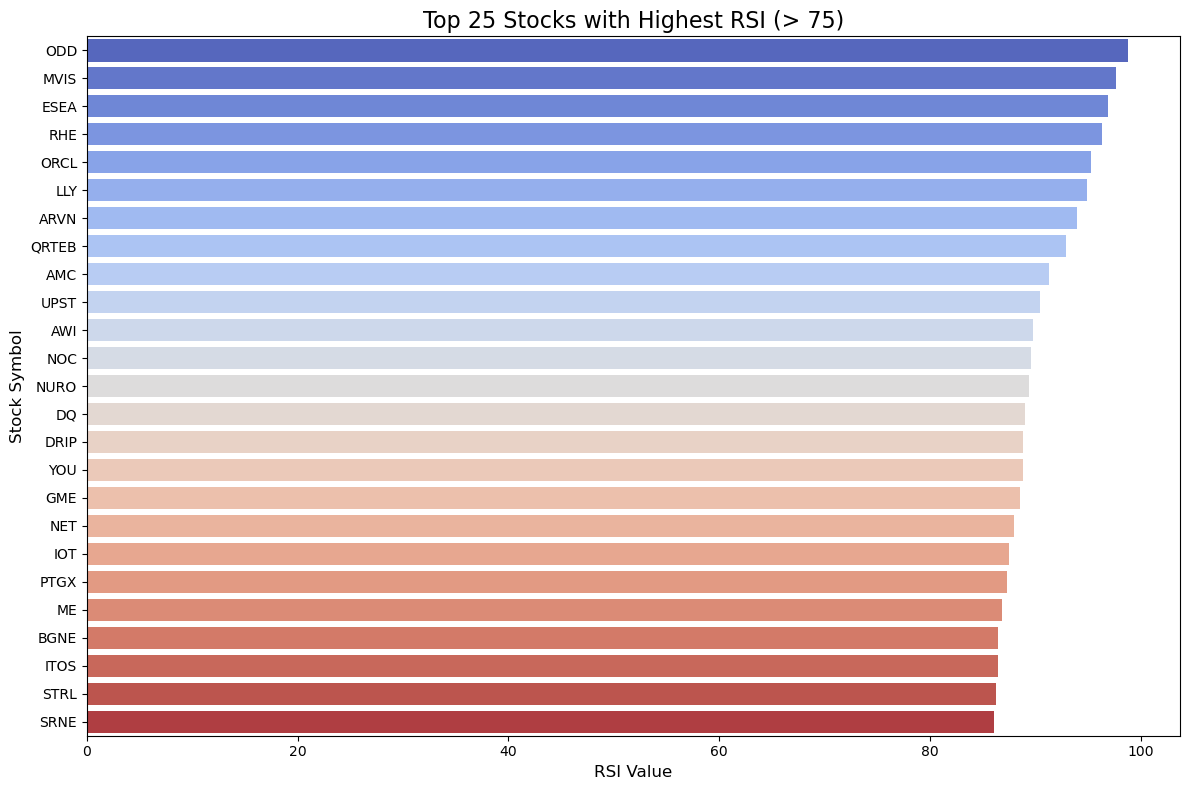

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert the Spark DataFrame to Pandas DataFrame
top_25_rsi_pandas = top_25_rsi_stocks.toPandas()

# Step 2: Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='rsi', y='symbol', data=top_25_rsi_pandas, palette='coolwarm')

# Add labels and title
plt.title('Top 25 Stocks with Highest RSI (> 75)', fontsize=16)
plt.xlabel('RSI Value', fontsize=12)
plt.ylabel('Stock Symbol', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()
